1. Download data and create Pandas DataFrame with training data

In [1]:
#Import necessary libraries and read the CSV file
import pandas as pd
import matplotlib.pyplot as plt
file='/home/yipeng/Desktop/Nanox81/nanox81_train_data.csv'
df=pd.read_csv(file)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381264 entries, 0 to 381263
Data columns (total 3 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   matpes_id                 381264 non-null  object 
 1   formula_pretty            381227 non-null  object 
 2   cohesive_energy_per_atom  381264 non-null  float64
dtypes: float64(1), object(2)
memory usage: 8.7+ MB


In [2]:
df.describe()

,cohesive_energy_per_atom
count,381264.000000
mean,-4.003174
std,1.350295
min,-13.740827
25%,-4.944208
50%,-4.009117
75%,-3.069164
max,3.651036


In [3]:
df.isnull().sum()

matpes_id                    0
formula_pretty              37
cohesive_energy_per_atom     0
dtype: int64

In [4]:
df.head()


,matpes_id,formula_pretty,cohesive_energy_per_atom
0,mp-862690,Ac,-3.549690
1,mp-1183069,Ac,-3.541488
2,mp-10018,Ac,-3.529483
3,mp-1183057,Ac,-3.526954
4,matpes-20240214_1183069_3,Ac,-3.445399


2. Plot histograms of E_c of the training data.

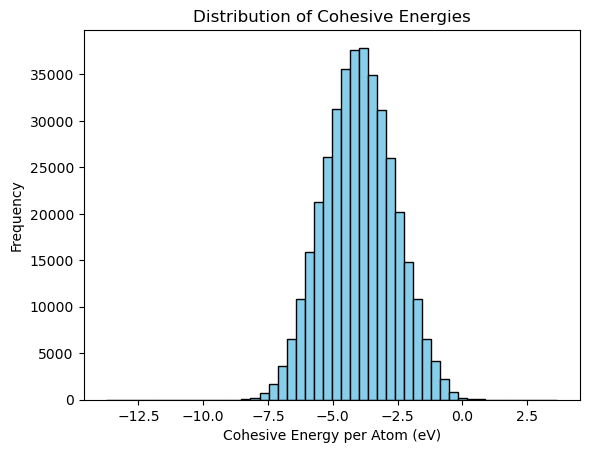

In [5]:
plt.hist(df["cohesive_energy_per_atom"], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Cohesive Energy per Atom (eV)")
plt.ylabel("Frequency")
plt.title("Distribution of Cohesive Energies")
plt.show()

3.


Generate composition-based and structure-based features for data.
1. import data file MatPES-R2SCAN
2. Check the data in MatPES-R2SCAN
3. Collect composition-based features and structure-based features; calculate volume per atom, extract sub-informations from complicated column, eg. [structure,etc]: Added ['lattice_a', 'lattice_b', 'lattice_c','lattice_alpha', 'lattice_beta', 'lattice_gamma', 'atomnic_density_from_struct']; calculate average minimum nearest neighbor distance for each structure: Added ['avg_min_nn_distance']; calculate the average coordination number for each structure: Added ['avg_cn_voronoi']; Get elemental properties using pymatgen
4. Clean data: Check missing values and delete duplicate columns; Impute numerical features with median; Check data types and convert to appropriate types; Check number of uinique values in non-numerical columns for further grouping
5. Save the processed DataFrame to a CSV file for future use as a library with columns
6. Convert non-numerical columns to categorical types and group them to reduce memory usage, perform one-hot encoding on categorical columns if needed
7. Save the processed DataFrame to a CSV for ML train and test data preparation


In [6]:
import json
from pymatgen.core.structure import Structure
import pandas as pd
from tqdm import tqdm
import gzip
file_path="/home/yipeng/Desktop/Nanox81/MatPES-R2SCAN-2025.1.json.gz"

# Load the r2SCAN.json.gz file correctly using gzip
with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    data = json.load(f)



In [7]:
# Convert to DataFrame and extract structure
records = []

for entry in tqdm(data):
    struct = Structure.from_dict(entry["structure"])  # Convert dict to pymatgen Structure object
    records.append({
        "matpes_id": entry["matpes_id"],
        "formula_pretty": entry["formula_pretty"],
        "cohesive_energy_per_atom": entry["cohesive_energy_per_atom"],
        "elements": entry["elements"],
        "nelements": entry["nelements"],
        "composition": entry["composition"],
        "composition_reduced": entry["composition_reduced"],
        "nsites": entry["nsites"],
        "volume": entry["volume"],
        "density": entry["density"],
        "density_per_atom": entry["density_atomic"],
        "structure": struct,
        "bandgap": entry["bandgap"],
        "functional": entry["functional"]
    })

dfr2scan = pd.DataFrame(records)

100%|██████████| 387897/387897 [01:33<00:00, 4163.16it/s] 


In [8]:
dfr2scan['volume_per_atom'] = dfr2scan['volume'] / dfr2scan['nsites']

In [9]:
#extract structure parameters into separate columns
dfr2scan['lattice_a'] = dfr2scan['structure'].apply(lambda s: s.lattice.a)
dfr2scan['lattice_b'] = dfr2scan['structure'].apply(lambda s: s.lattice.b)
dfr2scan['lattice_c'] = dfr2scan['structure'].apply(lambda s: s.lattice.c)
dfr2scan['lattice_alpha'] = dfr2scan['structure'].apply(lambda s: s.lattice.alpha)
dfr2scan['lattice_beta'] = dfr2scan['structure'].apply(lambda s: s.lattice.beta)
dfr2scan['lattice_gamma'] = dfr2scan['structure'].apply(lambda s: s.lattice.gamma)


In [10]:
dfr2scan['atomnic_density_from_struct']=dfr2scan['structure'].apply(lambda s:s.num_sites/s.lattice.volume)

In [11]:
#calculate the average minimum nearest neighbor distance for each structure
import numpy as np
def get_avg_min_nn_dist(struct):
    min_dists =[]
    if struct.num_sites == 1: # Handle single-atom unit cells if they exist
         # No neighbors within the same cell, concept might not apply or needs different handling
        return None # Or a placeholder
    for i in range(struct.num_sites):
        # Get neighbors for site i. The radius 'r' needs to be chosen carefully.
        neighbors = struct.get_neighbors(struct[i], r=4.0)
        if neighbors:
            # neighbors is a list of (site, distance, index, image_offset) tuples
            min_dists.append(min(neighbor_info[1] for neighbor_info in neighbors))
    return np.mean(min_dists) if min_dists else None
dfr2scan['avg_min_nn_distance'] = dfr2scan['structure'].apply(get_avg_min_nn_dist)

In [12]:
#Get more information about the structure
from pymatgen.analysis.local_env import VoronoiNN
from joblib import Parallel, delayed

# 1. Define the function to get average CN using VoronoiNN
vnn = VoronoiNN(allow_pathological=True, tol=0.8, cutoff=10.0) 
# 'tol': Tolerance for face area in Angstrom^2. Smaller values are stricter.
# 'cutoff': Cutoff radius in Angstroms. Voronoi cells are only constructed for atoms within this radius.

def get_avg_cn_voronoi(struct):
    """
    Calculates the average coordination number for a pymatgen Structure object
    using VoronoiNN.
    """
    if not isinstance(struct, Structure):
        return None
    try:
        cns =[]
        for i in range(struct.num_sites):
            cn = vnn.get_cn(struct, i, use_weights=False) 
            cns.append(cn)
        return np.mean(cns) if cns else 0.0
    except Exception as e:
        return None # Return None or np.nan for failures
n_jobs = -1 # Use all available CPU cores

# The list of structures to process
structures_to_process = dfr2scan['structure'].tolist()

print(f"Starting parallel processing with joblib using {n_jobs if n_jobs!= -1 else 'all'} cores...")

# Parallel execution
# The `Parallel` object from joblib handles the distribution of tasks.
# `delayed` is used to wrap the function and its arguments for lazy evaluation.
# `tqdm` is used here to wrap the iterable that Parallel processes.
results = Parallel(n_jobs=n_jobs)(
    delayed(get_avg_cn_voronoi)(struct) for struct in tqdm(structures_to_process, desc="Calculating Voronoi CN (Parallel)")
)

# Add the results back to the DataFrame
dfr2scan['avg_cn_voronoi'] = results
print("Parallel processing finished.")
print(dfr2scan[['structure', 'avg_cn_voronoi']].head())

Starting parallel processing with joblib using all cores...


Calculating Voronoi CN (Parallel):  16%|█▌        | 61056/387897 [03:32<37:14, 146.26it/s] /home/yipeng/miniconda3/envs/NANOx81/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Calculating Voronoi CN (Parallel): 100%|██████████| 387897/387897 [23:08<00:00, 279.38it/s] 


Parallel processing finished.
                                           structure  avg_cn_voronoi
0  [[1.16530002e+00 2.82883199e+00 2.30708860e-03...             4.0
1  [[0.97214618 4.81578699 0.20510329] Y, [2.9880...             1.0
2  [[3.43286398 3.85417943 0.125293  ] Y, [1.8065...             6.0
3  [[1.46003168 4.89700481 0.34483699] Y, [-0.454...             1.0
4  [[-2.10014425  8.85380003  0.53442291] Y, [-0....             4.0


In [14]:
dfr2scan.head()

,matpes_id,formula_pretty,cohesive_energy_per_atom,elements,nelements,composition,composition_reduced,nsites,volume,density,...,volume_per_atom,lattice_a,lattice_b,lattice_c,lattice_alpha,lattice_beta,lattice_gamma,atomnic_density_from_struct,avg_min_nn_distance,avg_cn_voronoi
0,matpes-20240214_999485_2,ZnN,-2.481338,"[N, Zn]",2,"{'Zn': 1.0, 'N': 1.0}","{'Zn': 1.0, 'N': 1.0}",2,22.207064,5.938330,...,11.103532,2.908515,3.062899,3.594986,52.923694,60.488855,70.576030,0.090061,1.928323,4.0
1,matpes-20240214_999484_70,YTi,-3.805109,"[Ti, Y]",2,"{'Y': 1.0, 'Ti': 1.0}","{'Y': 1.0, 'Ti': 1.0}",2,49.736736,4.566377,...,24.868368,3.082196,6.785060,3.503649,44.896203,75.952180,85.288097,0.040212,2.648196,1.0
2,matpes-20240214_999484_47,YTi,-4.156860,"[Ti, Y]",2,"{'Y': 1.0, 'Ti': 1.0}","{'Y': 1.0, 'Ti': 1.0}",2,50.392076,4.506992,...,25.196038,3.539674,4.033892,3.548328,86.959701,95.060777,91.050751,0.039689,2.995858,6.0
3,matpes-20240214_999484_26,YTi,-3.948170,"[Ti, Y]",2,"{'Y': 1.0, 'Ti': 1.0}","{'Y': 1.0, 'Ti': 1.0}",2,48.717972,4.661866,...,24.358986,2.983416,6.045412,3.252970,103.708772,119.050949,93.622677,0.041053,2.916790,1.0
4,matpes-20240214_999484_13,YTi,-3.810240,"[Ti, Y]",2,"{'Y': 1.0, 'Ti': 1.0}","{'Y': 1.0, 'Ti': 1.0}",2,52.719232,4.308042,...,26.359616,3.065595,11.077267,4.817893,154.116260,96.297738,101.064218,0.037937,2.796280,4.0


In [16]:
import numpy as np
import pandas as pd
from pymatgen.core import Composition, Element
import re
from tqdm.auto import tqdm

# Register `pandas.apply` with `tqdm` for a progress bar
tqdm.pandas()

def get_valence_electrons(element: Element) -> float:
    """Calculates the number of valence electrons for a pymatgen Element object."""
    try:
        structure = element.electronic_structure
        parts = structure.split(']')[-1].strip().split(' ')
        valence_count = 0
        for part in parts:
            numbers = re.findall(r'\d+', part)
            if len(numbers) > 1:
                valence_count += int(numbers[-1])
        return float(valence_count)
    except (AttributeError, IndexError, ValueError):
        return np.nan


def get_composition_features(composition_input) -> dict:
    """Calculates statistics of elemental properties for a given chemical composition."""
    
    # List of elemental properties to extract from pymatgen
    PROPERTIES_TO_EXTRACT = [
        ("atomic_mass",       lambda el: el.atomic_mass),
        ("atomic_radius",     lambda el: el.atomic_radius),
        ("ionic_radius",      lambda el: el.average_ionic_radius),
        ("electronegativity", lambda el: el.X),
        ("mendeleev_no",      lambda el: el.mendeleev_no),
        ("melting_point",     lambda el: el.melting_point),
        ("boiling_point",     lambda el: el.boiling_point),
        ("valence",           get_valence_electrons)
    ]
    
    nan_features = {}
    for prop_name, _ in PROPERTIES_TO_EXTRACT:
        for stat in ["avg",  "range"]:
            nan_features[f"{stat}_{prop_name}"] = np.nan

    if composition_input is None or not isinstance(composition_input, (str, dict)):
        return nan_features

    features = {}
    
    try:
        composition = Composition(composition_input)
        elements = composition.elements
        weights = [composition.get_atomic_fraction(el) for el in elements]

        for prop_name, prop_func in PROPERTIES_TO_EXTRACT:
            values = [prop_func(el) for el in elements]
            valid_values_weights = [(v, w) for v, w in zip(values, weights) if v is not None]
            
            if not valid_values_weights:
                stats = [np.nan, np.nan, np.nan, np.nan]
            else:
                valid_values, valid_weights = zip(*valid_values_weights)
                stats = [
                    np.average(valid_values, weights=valid_weights),
                    np.max(valid_values) - np.min(valid_values)
                ]

            features[f"avg_{prop_name}"] = stats[0]
            features[f"range_{prop_name}"] = stats[1]
            
        return features

    except Exception as e:
        print(f"Could not process input '{composition_input}'. Reason: {e}")
        return nan_features

In [18]:
elemental_features_df = dfr2scan['formula_pretty'].progress_apply(
    lambda formula: pd.Series(get_composition_features(formula)))


  0%|          | 0/387897 [00:00<?, ?it/s]

/tmp/ipykernel_55473/1311561344.py:36: UserWarning: No data available for boiling_point for Pa
  ("boiling_point",     lambda el: el.boiling_point),
/tmp/ipykernel_55473/1311561344.py:33: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  ("electronegativity", lambda el: el.X),
/tmp/ipykernel_55473/1311561344.py:33: UserWarning: No Pauling electronegativity for Ar. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  ("electronegativity", lambda el: el.X),
/tmp/ipykernel_55473/1311561344.py:33: UserWarning: No Pauling electronegativity for Ne. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  ("electronegativity", lambda el: el.X),


In [19]:

elemental_features_df

,avg_atomic_mass,range_atomic_mass,avg_atomic_radius,range_atomic_radius,avg_ionic_radius,range_ionic_radius,avg_electronegativity,range_electronegativity,avg_mendeleev_no,range_mendeleev_no,avg_melting_point,range_melting_point,avg_boiling_point,range_boiling_point,avg_valence,range_valence
0,39.707850,51.402300,1.000000,0.70,0.755000,0.250000,2.345000,1.39,88.000000,24.0,377.865000,629.63,628.680000,1102.64,2.500000,1.0
1,68.386425,41.038850,1.600000,0.40,0.945833,0.188333,1.380000,0.32,38.000000,26.0,1870.000000,142.00,3584.500000,49.00,2.000000,0.0
2,68.386425,41.038850,1.600000,0.40,0.945833,0.188333,1.380000,0.32,38.000000,26.0,1870.000000,142.00,3584.500000,49.00,2.000000,0.0
3,68.386425,41.038850,1.600000,0.40,0.945833,0.188333,1.380000,0.32,38.000000,26.0,1870.000000,142.00,3584.500000,49.00,2.000000,0.0
4,68.386425,41.038850,1.600000,0.40,0.945833,0.188333,1.380000,0.32,38.000000,26.0,1870.000000,142.00,3584.500000,49.00,2.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387892,64.193800,72.415200,1.550000,1.35,1.124444,0.880000,2.175000,2.34,64.333333,90.0,395.775000,1063.33,845.721667,2195.89,3.000000,4.0
387893,21.968978,51.992195,1.008333,0.85,1.061667,0.491667,2.370000,2.46,67.000000,89.0,507.309583,1713.20,1110.641667,3109.80,2.708333,3.0
387894,24.984901,38.938645,0.800000,0.80,1.077917,0.710000,2.916667,1.89,92.333333,41.0,342.583333,1464.20,540.800000,2243.80,3.500000,2.0
387895,62.958950,167.840600,0.912500,1.25,1.158208,0.493333,2.947500,2.24,83.916667,83.0,846.860833,3640.20,1384.383333,5737.80,3.250000,3.0


In [21]:

# Join the new features back to your original DataFrame
dfr2scan_with_features = dfr2scan.join(elemental_features_df)

# Display the first few rows with the new features
dfr2scan_with_features.head()

,matpes_id,formula_pretty,cohesive_energy_per_atom,elements,nelements,composition,composition_reduced,nsites,volume,density,...,avg_electronegativity,range_electronegativity,avg_mendeleev_no,range_mendeleev_no,avg_melting_point,range_melting_point,avg_boiling_point,range_boiling_point,avg_valence,range_valence
0,matpes-20240214_999485_2,ZnN,-2.481338,"[N, Zn]",2,"{'Zn': 1.0, 'N': 1.0}","{'Zn': 1.0, 'N': 1.0}",2,22.207064,5.938330,...,2.345,1.39,88.0,24.0,377.865,629.63,628.68,1102.64,2.5,1.0
1,matpes-20240214_999484_70,YTi,-3.805109,"[Ti, Y]",2,"{'Y': 1.0, 'Ti': 1.0}","{'Y': 1.0, 'Ti': 1.0}",2,49.736736,4.566377,...,1.380,0.32,38.0,26.0,1870.000,142.00,3584.50,49.00,2.0,0.0
2,matpes-20240214_999484_47,YTi,-4.156860,"[Ti, Y]",2,"{'Y': 1.0, 'Ti': 1.0}","{'Y': 1.0, 'Ti': 1.0}",2,50.392076,4.506992,...,1.380,0.32,38.0,26.0,1870.000,142.00,3584.50,49.00,2.0,0.0
3,matpes-20240214_999484_26,YTi,-3.948170,"[Ti, Y]",2,"{'Y': 1.0, 'Ti': 1.0}","{'Y': 1.0, 'Ti': 1.0}",2,48.717972,4.661866,...,1.380,0.32,38.0,26.0,1870.000,142.00,3584.50,49.00,2.0,0.0
4,matpes-20240214_999484_13,YTi,-3.810240,"[Ti, Y]",2,"{'Y': 1.0, 'Ti': 1.0}","{'Y': 1.0, 'Ti': 1.0}",2,52.719232,4.308042,...,1.380,0.32,38.0,26.0,1870.000,142.00,3584.50,49.00,2.0,0.0


In [23]:
dfr2scan_with_features.columns

Index(['matpes_id', 'formula_pretty', 'cohesive_energy_per_atom', 'elements',
       'nelements', 'composition', 'composition_reduced', 'nsites', 'volume',
       'density', 'density_per_atom', 'structure', 'bandgap', 'functional',
       'volume_per_atom', 'lattice_a', 'lattice_b', 'lattice_c',
       'lattice_alpha', 'lattice_beta', 'lattice_gamma',
       'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi',
       'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius',
       'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius',
       'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no',
       'range_mendeleev_no', 'avg_melting_point', 'range_melting_point',
       'avg_boiling_point', 'range_boiling_point', 'avg_valence',
       'range_valence'],
      dtype='object')

In [26]:
dfr2scan_with_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 387897 entries, 0 to 387896
Data columns (total 40 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   matpes_id                    387897 non-null  object 
 1   formula_pretty               387897 non-null  object 
 2   cohesive_energy_per_atom     387897 non-null  float64
 3   elements                     387897 non-null  object 
 4   nelements                    387897 non-null  int64  
 5   composition                  387897 non-null  object 
 6   composition_reduced          387897 non-null  object 
 7   nsites                       387897 non-null  int64  
 8   volume                       387897 non-null  float64
 9   density                      387897 non-null  float64
 10  density_per_atom             387897 non-null  float64
 11  structure                    387897 non-null  object 
 12  bandgap                      387897 non-null  float64
 13 

In [30]:
#check for missing values in the new features
missing_features = dfr2scan_with_features.isnull().sum()
print("Missing values in new features:")
print(missing_features[missing_features > 0])

Missing values in new features:
avg_min_nn_distance        990
avg_cn_voronoi             952
avg_atomic_radius           46
range_atomic_radius         46
avg_electronegativity       89
range_electronegativity     89
avg_boiling_point           48
range_boiling_point         48
dtype: int64


In [32]:
#check missing values type
missing_features_types = dfr2scan_with_features.dtypes[missing_features > 0]
print("Data types of features with missing values:")
print(missing_features_types)

Data types of features with missing values:
avg_min_nn_distance        float64
avg_cn_voronoi             float64
avg_atomic_radius          float64
range_atomic_radius        float64
avg_electronegativity      float64
range_electronegativity    float64
avg_boiling_point          float64
range_boiling_point        float64
dtype: object


In [ ]:
# Let's assume your final DataFrame is called `df_ml`
total_rows = len(dfr2scan_with_features)
missing_structural_percentage = (990 / total_rows) * 100
print(f"The structural features are missing in {missing_structural_percentage:.2f}% of the rows.")

The structural features are missing in 0.26% of the rows.


The structural features are missing in 0.26% of the rows.


The structural features are missing in 0.26% of the rows.


In [35]:
#Impute numerical features with their median
import numpy as np # Make sure numpy is imported
from sklearn.impute import SimpleImputer
# ---  Impute numerical features with their median ---
numerical_cols_to_impute = [
    'avg_min_nn_distance',
    'avg_cn_voronoi',
    'avg_atomic_radius',
    'range_atomic_radius',
    'avg_electronegativity', 
    'range_electronegativity', 
    'avg_boiling_point',
    'range_boiling_point', 
]

imputer_median = SimpleImputer(strategy='median')

for col in numerical_cols_to_impute:
    if col in dfr2scan_with_features.columns:
        # Reshape data for SimpleImputer (it expects 2D array)
        dfr2scan_with_features[col] = imputer_median.fit_transform(dfr2scan_with_features[[col]])
        print(f"Imputed NaNs in '{col}' with median.")
    else:
        print(f"Warning: Column '{col}' not found for imputation.")


Imputed NaNs in 'avg_min_nn_distance' with median.
Imputed NaNs in 'avg_cn_voronoi' with median.
Imputed NaNs in 'avg_atomic_radius' with median.
Imputed NaNs in 'range_atomic_radius' with median.
Imputed NaNs in 'avg_electronegativity' with median.
Imputed NaNs in 'range_electronegativity' with median.
Imputed NaNs in 'avg_boiling_point' with median.
Imputed NaNs in 'range_boiling_point' with median.


In [36]:

# Verify NaNs are handled for these columns
print("\nMissing values after imputation:")
print(dfr2scan_with_features[numerical_cols_to_impute].isnull().sum())


Missing values after imputation:
avg_min_nn_distance        0
avg_cn_voronoi             0
avg_atomic_radius          0
range_atomic_radius        0
avg_electronegativity      0
range_electronegativity    0
avg_boiling_point          0
range_boiling_point        0
dtype: int64


In [37]:

# Also, check the data types to confirm which are objects (likely categorical) and which are numbers
print("\nData types of columns:")
print(dfr2scan_with_features.dtypes)


Data types of columns:
matpes_id                       object
formula_pretty                  object
cohesive_energy_per_atom       float64
elements                        object
nelements                        int64
composition                     object
composition_reduced             object
nsites                           int64
volume                         float64
density                        float64
density_per_atom               float64
structure                       object
bandgap                        float64
functional                      object
volume_per_atom                float64
lattice_a                      float64
lattice_b                      float64
lattice_c                      float64
lattice_alpha                  float64
lattice_beta                   float64
lattice_gamma                  float64
atomnic_density_from_struct    float64
avg_min_nn_distance            float64
avg_cn_voronoi                 float64
avg_atomic_mass                float64
r

In [43]:
#build a dafaframe with current one to save as a copy
dfr2scan_copy = dfr2scan_with_features.copy()
columns_to_drop_before_encoding =["composition","composition_reduced","structure"]

# Drop columns that exist
existing_columns_to_drop = [col for col in columns_to_drop_before_encoding if col in dfr2scan_with_features.columns]
dfr2scan_with_features.drop(columns=existing_columns_to_drop, inplace=True)
print(f"\nDropped columns: {existing_columns_to_drop}")

print("\nDataFrame columns after dropping:")
print(dfr2scan_with_features.columns)


Dropped columns: []

DataFrame columns after dropping:
Index(['matpes_id', 'formula_pretty', 'cohesive_energy_per_atom', 'elements',
       'nelements', 'nsites', 'volume', 'density', 'density_per_atom',
       'bandgap', 'functional', 'volume_per_atom', 'lattice_a', 'lattice_b',
       'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma',
       'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi',
       'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius',
       'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius',
       'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no',
       'range_mendeleev_no', 'avg_melting_point', 'range_melting_point',
       'avg_boiling_point', 'range_boiling_point', 'avg_valence',
       'range_valence'],
      dtype='object')


In [44]:
dfr2scan_with_features

,matpes_id,formula_pretty,cohesive_energy_per_atom,elements,nelements,nsites,volume,density,density_per_atom,bandgap,...,avg_electronegativity,range_electronegativity,avg_mendeleev_no,range_mendeleev_no,avg_melting_point,range_melting_point,avg_boiling_point,range_boiling_point,avg_valence,range_valence
0,matpes-20240214_999485_2,ZnN,-2.481338,"[N, Zn]",2,2,22.207064,5.938330,11.103532,0.0000,...,2.345000,1.39,88.000000,24.0,377.865000,629.63,628.680000,1102.64,2.500000,1.0
1,matpes-20240214_999484_70,YTi,-3.805109,"[Ti, Y]",2,2,49.736736,4.566377,24.868368,0.0000,...,1.380000,0.32,38.000000,26.0,1870.000000,142.00,3584.500000,49.00,2.000000,0.0
2,matpes-20240214_999484_47,YTi,-4.156860,"[Ti, Y]",2,2,50.392076,4.506992,25.196038,0.0000,...,1.380000,0.32,38.000000,26.0,1870.000000,142.00,3584.500000,49.00,2.000000,0.0
3,matpes-20240214_999484_26,YTi,-3.948170,"[Ti, Y]",2,2,48.717972,4.661866,24.358986,0.0000,...,1.380000,0.32,38.000000,26.0,1870.000000,142.00,3584.500000,49.00,2.000000,0.0
4,matpes-20240214_999484_13,YTi,-3.810240,"[Ti, Y]",2,2,52.719232,4.308042,26.359616,0.0000,...,1.380000,0.32,38.000000,26.0,1870.000000,142.00,3584.500000,49.00,2.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387892,mp-29693,Rb2AgCl3,-3.047314,"[Ag, Cl, Rb]",3,24,739.967830,3.457328,30.831993,3.4839,...,2.175000,2.34,64.333333,90.0,395.775000,1063.33,845.721667,2195.89,3.000000,4.0
387893,mp-1174866,Li7Mn2(CoO4)3,-4.665980,"[Co, Li, Mn, O]",4,24,216.206334,4.049504,9.008597,0.0000,...,2.370000,2.46,67.000000,89.0,507.309583,1713.20,1110.641667,3109.80,2.708333,3.0
387894,mp-26980,MnPO4,-5.234824,"[Mn, O, P]",3,24,274.761909,3.623944,11.448413,0.1406,...,2.916667,1.89,92.333333,41.0,342.583333,1464.20,540.800000,2243.80,3.500000,2.0
387895,mp-1213000,EuAg(WO4)2,-5.860940,"[Ag, Eu, O, W]",4,24,337.131324,7.442498,14.047139,0.0806,...,2.947500,2.24,83.916667,83.0,846.860833,3640.20,1384.383333,5737.80,3.250000,3.0


In [46]:
#save the dataset to csv file
dfr2scan_with_features.to_csv('/home/yipeng/Desktop/Nanox81/library1.csv', index=False)

In [56]:
dfr2scan_cleaned_final= dfr2scan_with_features.copy()

In [59]:
dfr2scan_cleaned_final.columns

Index(['matpes_id', 'formula_pretty', 'cohesive_energy_per_atom', 'elements',
       'nelements', 'nsites', 'volume', 'density', 'density_per_atom',
       'bandgap', 'functional', 'volume_per_atom', 'lattice_a', 'lattice_b',
       'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma',
       'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi',
       'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius',
       'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius',
       'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no',
       'range_mendeleev_no', 'avg_melting_point', 'range_melting_point',
       'avg_boiling_point', 'range_boiling_point', 'avg_valence',
       'range_valence'],
      dtype='object')

In [60]:
dfr2scan_cleaned_final['elements']

0                 [N, Zn]
1                 [Ti, Y]
2                 [Ti, Y]
3                 [Ti, Y]
4                 [Ti, Y]
               ...       
387892       [Ag, Cl, Rb]
387893    [Co, Li, Mn, O]
387894         [Mn, O, P]
387895     [Ag, Eu, O, W]
387896    [Co, Li, Mn, O]
Name: elements, Length: 387897, dtype: object

In [61]:
from pymatgen.core import Element

def get_chemsys_features(element_list):
    features = {
        'has_transition_metal': 0,
        'is_oxide_system': 0,
        'has_halogen': 0,
        'has_alkali_metal': 0,
        'has_alkaline_earth_metal': 0,
        'has_chalcogen_not_O': 0, # S, Se, Te
        'has_pnictogen_not_N':0 # P, As, Sb, Bi
    }
    elements_pymatgen = [Element(el) for el in element_list]

    for el_obj in elements_pymatgen:
        if el_obj.is_transition_metal:
            features['has_transition_metal'] = 1
        if el_obj.symbol == 'O':
            features['is_oxide_system'] = 1
        if el_obj.is_halogen:
            features['has_halogen'] = 1
        if el_obj.is_alkali:
            features['has_alkali_metal'] = 1
        if el_obj.is_alkaline:
            features['has_alkaline_earth_metal'] = 1
        if el_obj.symbol in ['S', 'Se', 'Te']:
            features['has_chalcogen_not_O'] = 1
        if el_obj.symbol in ['P', 'As', 'Sb', 'Bi']: 
            features['has_pnictogen_not_N'] = 1
    return pd.Series(features)


chemsys_derived_features = dfr2scan_cleaned_final['elements'].apply(get_chemsys_features)
dfr2scan_with_chemsys_features = pd.concat([dfr2scan_cleaned_final, chemsys_derived_features], axis=1)

In [62]:
dfr2scan_with_chemsys_features

,matpes_id,formula_pretty,cohesive_energy_per_atom,elements,nelements,nsites,volume,density,density_per_atom,bandgap,...,range_boiling_point,avg_valence,range_valence,has_transition_metal,is_oxide_system,has_halogen,has_alkali_metal,has_alkaline_earth_metal,has_chalcogen_not_O,has_pnictogen_not_N
0,matpes-20240214_999485_2,ZnN,-2.481338,"[N, Zn]",2,2,22.207064,5.938330,11.103532,0.0000,...,1102.64,2.500000,1.0,1,0,0,0,0,0,0
1,matpes-20240214_999484_70,YTi,-3.805109,"[Ti, Y]",2,2,49.736736,4.566377,24.868368,0.0000,...,49.00,2.000000,0.0,1,0,0,0,0,0,0
2,matpes-20240214_999484_47,YTi,-4.156860,"[Ti, Y]",2,2,50.392076,4.506992,25.196038,0.0000,...,49.00,2.000000,0.0,1,0,0,0,0,0,0
3,matpes-20240214_999484_26,YTi,-3.948170,"[Ti, Y]",2,2,48.717972,4.661866,24.358986,0.0000,...,49.00,2.000000,0.0,1,0,0,0,0,0,0
4,matpes-20240214_999484_13,YTi,-3.810240,"[Ti, Y]",2,2,52.719232,4.308042,26.359616,0.0000,...,49.00,2.000000,0.0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387892,mp-29693,Rb2AgCl3,-3.047314,"[Ag, Cl, Rb]",3,24,739.967830,3.457328,30.831993,3.4839,...,2195.89,3.000000,4.0,1,0,1,1,0,0,0
387893,mp-1174866,Li7Mn2(CoO4)3,-4.665980,"[Co, Li, Mn, O]",4,24,216.206334,4.049504,9.008597,0.0000,...,3109.80,2.708333,3.0,1,1,0,1,0,0,0
387894,mp-26980,MnPO4,-5.234824,"[Mn, O, P]",3,24,274.761909,3.623944,11.448413,0.1406,...,2243.80,3.500000,2.0,1,1,0,0,0,0,1
387895,mp-1213000,EuAg(WO4)2,-5.860940,"[Ag, Eu, O, W]",4,24,337.131324,7.442498,14.047139,0.0806,...,5737.80,3.250000,3.0,1,1,0,0,0,0,0


In [67]:
#Save final processed DataFrame to CSV
dfr2scan_with_chemsys_features.to_csv("/home/yipeng/Desktop/Nanox81/librarygroup.csv", index=False)

In [3]:
import pandas as pd
dfr2scan_with_chemsys_features=pd.read_csv("/home/yipeng/Desktop/Nanox81/librarygroup.csv")

In [4]:
dfr2scan_with_chemsys_features.columns

Index(['matpes_id', 'formula_pretty', 'cohesive_energy_per_atom', 'elements',
       'nelements', 'nsites', 'volume', 'density', 'density_per_atom',
       'bandgap', 'functional', 'volume_per_atom', 'lattice_a', 'lattice_b',
       'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma',
       'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi',
       'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius',
       'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius',
       'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no',
       'range_mendeleev_no', 'avg_melting_point', 'range_melting_point',
       'avg_boiling_point', 'range_boiling_point', 'avg_valence',
       'range_valence', 'has_transition_metal', 'is_oxide_system',
       'has_halogen', 'has_alkali_metal', 'has_alkaline_earth_metal',
       'has_chalcogen_not_O', 'has_pnictogen_not_N'],
      dtype='object')

In [12]:
dfr2scan_with_chemsys_features.head()

,matpes_id,formula_pretty,cohesive_energy_per_atom,elements,nelements,nsites,volume,density,density_per_atom,bandgap,...,range_boiling_point,avg_valence,range_valence,has_transition_metal,is_oxide_system,has_halogen,has_alkali_metal,has_alkaline_earth_metal,has_chalcogen_not_O,has_pnictogen_not_N
0,matpes-20240214_999485_2,ZnN,-2.481338,"['N', 'Zn']",2,2,22.207064,5.938330,11.103532,0.0,...,1102.64,2.5,1.0,1,0,0,0,0,0,0
1,matpes-20240214_999484_70,YTi,-3.805109,"['Ti', 'Y']",2,2,49.736736,4.566377,24.868368,0.0,...,49.00,2.0,0.0,1,0,0,0,0,0,0
2,matpes-20240214_999484_47,YTi,-4.156860,"['Ti', 'Y']",2,2,50.392076,4.506992,25.196038,0.0,...,49.00,2.0,0.0,1,0,0,0,0,0,0
3,matpes-20240214_999484_26,YTi,-3.948170,"['Ti', 'Y']",2,2,48.717972,4.661866,24.358986,0.0,...,49.00,2.0,0.0,1,0,0,0,0,0,0
4,matpes-20240214_999484_13,YTi,-3.810240,"['Ti', 'Y']",2,2,52.719232,4.308042,26.359616,0.0,...,49.00,2.0,0.0,1,0,0,0,0,0,0


In [15]:
dfr2scan_with_chemsys_features.iloc[0]

matpes_id                      matpes-20240214_999485_2
formula_pretty                                      ZnN
cohesive_energy_per_atom                      -2.481338
elements                                    ['N', 'Zn']
nelements                                             2
nsites                                                2
volume                                        22.207064
density                                         5.93833
density_per_atom                              11.103532
bandgap                                             0.0
functional                                       r2SCAN
volume_per_atom                               11.103532
lattice_a                                      2.908515
lattice_b                                      3.062899
lattice_c                                      3.594986
lattice_alpha                                 52.923694
lattice_beta                                  60.488855
lattice_gamma                                  7

ML training

Data preparation

1. Import previous saved file as a library to prepare training and test data
2. Import train_data and test_data from CSV
3. Pair the train and test data with library based on matpes_id to get the features used for machine learning
4. Prepare correct columns for training and test data
5. Split the training data into training and validation sets, get X_train, X_val, y_train, y_val
6. Scale the features using StandardScaler
7. Run ML models and optimize hyperparameters and evaluate the performance


In [14]:
#import data from csv
import pandas as pd
libraryafterencoding=pd.read_csv('/Users/ruhanfan/Documents/UCSD/3.课程学习资料/12. 25 SPRING/NANO281 Data Science in Material Science/ipynb file/Lab3 final/librarygroup.csv')
train=pd.read_csv('/Users/ruhanfan/Documents/UCSD/3.课程学习资料/12. 25 SPRING/NANO281 Data Science in Material Science/ipynb file/Lab3 final/nanox81_train_data.csv')
train=pd.merge(train, libraryafterencoding, on='matpes_id', how='left',suffixes=('', '_r2scan'))


In [15]:
train.columns

Index(['matpes_id', 'formula_pretty', 'cohesive_energy_per_atom', 'formula_pretty_r2scan', 'cohesive_energy_per_atom_r2scan', 'elements', 'nelements', 'nsites', 'volume', 'density', 'density_per_atom', 'bandgap', 'functional', 'volume_per_atom', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma', 'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi', 'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius', 'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius', 'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no', 'range_mendeleev_no', 'avg_melting_point', 'range_melting_point', 'avg_boiling_point', 'range_boiling_point', 'avg_valence', 'range_valence', 'has_transition_metal', 'is_oxide_system', 'has_halogen', 'has_alkali_metal', 'has_alkaline_earth_metal', 'has_chalcogen_not_O', 'has_pnictogen_not_N'], dtype='object')

In [16]:
train_data=train.drop(columns=['matpes_id','formula_pretty','cohesive_energy_per_atom_r2scan', 'formula_pretty_r2scan','elements','functional'])

In [17]:
train_data.columns

Index(['cohesive_energy_per_atom', 'nelements', 'nsites', 'volume', 'density', 'density_per_atom', 'bandgap', 'volume_per_atom', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma', 'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi', 'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius', 'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius', 'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no', 'range_mendeleev_no', 'avg_melting_point', 'range_melting_point', 'avg_boiling_point', 'range_boiling_point', 'avg_valence', 'range_valence', 'has_transition_metal', 'is_oxide_system', 'has_halogen', 'has_alkali_metal', 'has_alkaline_earth_metal', 'has_chalcogen_not_O', 'has_pnictogen_not_N'], dtype='object')

In [19]:
X = train_data.drop(columns=['cohesive_energy_per_atom','avg_boiling_point', 'range_boiling_point','avg_melting_point', 'range_melting_point'])
y = train_data['cohesive_energy_per_atom']

In [20]:
X.columns

Index(['nelements', 'nsites', 'volume', 'density', 'density_per_atom', 'bandgap', 'volume_per_atom', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma', 'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi', 'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius', 'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius', 'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no', 'range_mendeleev_no', 'avg_valence', 'range_valence', 'has_transition_metal', 'is_oxide_system', 'has_halogen', 'has_alkali_metal', 'has_alkaline_earth_metal', 'has_chalcogen_not_O', 'has_pnictogen_not_N'], dtype='object')

In [21]:
#Import test data
test=pd.read_csv('/Users/ruhanfan/Documents/UCSD/3.课程学习资料/12. 25 SPRING/NANO281 Data Science in Material Science/ipynb file/Lab3 final/nanox81_test_data.csv')
test=pd.merge(test, libraryafterencoding, on='matpes_id', how='left',suffixes=('', '_r2scan'))
test.columns

Index(['matpes_id', 'formula_pretty', 'formula_pretty_r2scan', 'cohesive_energy_per_atom', 'elements', 'nelements', 'nsites', 'volume', 'density', 'density_per_atom', 'bandgap', 'functional', 'volume_per_atom', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma', 'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi', 'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius', 'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius', 'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no', 'range_mendeleev_no', 'avg_melting_point', 'range_melting_point', 'avg_boiling_point', 'range_boiling_point', 'avg_valence', 'range_valence', 'has_transition_metal', 'is_oxide_system', 'has_halogen', 'has_alkali_metal', 'has_alkaline_earth_metal', 'has_chalcogen_not_O', 'has_pnictogen_not_N'], dtype='object')

In [24]:
test_data = test.drop(columns=['matpes_id','formula_pretty', 'cohesive_energy_per_atom', 'formula_pretty_r2scan','functional','elements','avg_melting_point', 'range_melting_point','avg_boiling_point', 'range_boiling_point'])
test_data.columns

Index(['nelements', 'nsites', 'volume', 'density', 'density_per_atom', 'bandgap', 'volume_per_atom', 'lattice_a', 'lattice_b', 'lattice_c', 'lattice_alpha', 'lattice_beta', 'lattice_gamma', 'atomnic_density_from_struct', 'avg_min_nn_distance', 'avg_cn_voronoi', 'avg_atomic_mass', 'range_atomic_mass', 'avg_atomic_radius', 'range_atomic_radius', 'avg_ionic_radius', 'range_ionic_radius', 'avg_electronegativity', 'range_electronegativity', 'avg_mendeleev_no', 'range_mendeleev_no', 'avg_valence', 'range_valence', 'has_transition_metal', 'is_oxide_system', 'has_halogen', 'has_alkali_metal', 'has_alkaline_earth_metal', 'has_chalcogen_not_O', 'has_pnictogen_not_N'], dtype='object')

In [25]:
#Split the data into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# Check the shapes of the training and validation sets and test set
print(f"Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}, Test set shape: {test_data.shape}")



Training set shape: (305011, 35), Validation set shape: (76253, 35), Test set shape: (6345, 35)


In [26]:
X_train.head()

,nelements,nsites,volume,density,density_per_atom,bandgap,volume_per_atom,lattice_a,lattice_b,lattice_c,lattice_alpha,lattice_beta,lattice_gamma,atomnic_density_from_struct,avg_min_nn_distance,avg_cn_voronoi,avg_atomic_mass,range_atomic_mass,avg_atomic_radius,range_atomic_radius,avg_ionic_radius,range_ionic_radius,avg_electronegativity,range_electronegativity,avg_mendeleev_no,range_mendeleev_no,avg_valence,range_valence,has_transition_metal,is_oxide_system,has_halogen,has_alkali_metal,has_alkaline_earth_metal,has_chalcogen_not_O,has_pnictogen_not_N
40265,5,10,132.591027,6.562458,13.259103,0.0,13.259103,5.723694,5.723694,5.723694,60.000000,60.000000,60.000000,0.075420,2.132876,4.80,52.400034,192.981000,1.010,1.25,1.16085,0.5850,2.6470,2.44,80.70,85.0,3.20,3.0,0,1,0,0,1,0,1
11430,2,2,108.365524,2.279241,54.182762,0.0,54.182762,4.376077,3.781315,7.273836,98.802683,95.507398,65.737501,0.018456,2.642711,3.00,74.370769,94.778461,1.350,0.20,0.75250,0.1550,1.8300,0.44,84.00,8.0,2.00,2.0,0,0,0,0,0,0,1
27052,3,4,41.884075,10.775872,10.471019,0.0,10.471019,5.747006,2.631503,3.896467,90.167551,86.813094,134.537439,0.095502,2.221148,1.25,67.950441,186.071818,1.200,0.30,0.68125,0.2150,1.8325,0.71,72.25,10.0,1.75,1.0,1,0,0,0,1,0,0
8628,2,2,27.027290,5.088808,13.513645,0.0,13.513645,2.903298,2.975691,3.465291,107.888322,96.044640,71.564788,0.073999,2.205532,2.00,41.413269,28.863461,1.325,0.15,0.76375,0.1775,1.7200,0.22,70.50,19.0,1.50,1.0,1,0,0,0,0,0,0
182827,4,5,61.146045,3.150344,12.229209,0.0,12.229209,2.956414,2.948130,7.071911,92.892653,83.576505,92.012280,0.081771,1.556541,2.60,23.201028,57.685460,0.860,1.25,0.82400,1.2600,2.4600,2.13,89.00,36.0,2.60,3.0,1,1,0,0,1,0,0


In [27]:
test_data.head()

,nelements,nsites,volume,density,density_per_atom,bandgap,volume_per_atom,lattice_a,lattice_b,lattice_c,lattice_alpha,lattice_beta,lattice_gamma,atomnic_density_from_struct,avg_min_nn_distance,avg_cn_voronoi,avg_atomic_mass,range_atomic_mass,avg_atomic_radius,range_atomic_radius,avg_ionic_radius,range_ionic_radius,avg_electronegativity,range_electronegativity,avg_mendeleev_no,range_mendeleev_no,avg_valence,range_valence,has_transition_metal,is_oxide_system,has_halogen,has_alkali_metal,has_alkaline_earth_metal,has_chalcogen_not_O,has_pnictogen_not_N
0,3,4,65.968465,9.173574,16.492116,0.0,16.492116,4.535416,4.535416,4.535416,60.000000,60.000000,60.000000,0.060635,2.777357,8.000000,91.109962,33.1825,1.450000,0.50,0.822500,0.295000,1.897500,1.06,59.000000,56.0,1.250000,1.0,1,0,0,0,0,0,0
1,2,16,285.617625,3.947797,17.851102,0.0,17.851102,7.392080,7.392080,7.392080,60.000000,60.000000,60.000000,0.056019,1.997242,3.000000,42.439550,105.7606,0.812500,0.85,1.152500,0.430000,3.092500,1.39,97.750000,13.0,3.750000,1.0,0,1,0,0,0,0,1
2,3,4,95.646334,6.387374,23.911584,0.0,23.911584,3.292745,14.444213,4.703633,153.927712,100.090402,84.793611,0.041821,2.911355,4.000000,91.977500,176.2850,1.487500,0.05,0.948750,0.415000,1.645000,0.69,75.750000,10.0,2.000000,0.0,1,0,0,0,1,0,0
3,3,22,560.184063,6.944767,25.462912,0.0,25.462912,6.996181,7.979577,11.278262,86.446113,101.568624,114.710557,0.039273,2.673867,3.090909,106.491922,64.0540,1.404545,0.10,1.078182,0.473333,1.927273,0.50,77.727273,39.0,2.636364,3.0,1,0,0,0,0,1,0
4,3,4,80.008483,9.763731,20.002121,0.0,20.002121,5.494934,10.141830,3.177186,73.411872,28.736684,80.782616,0.049995,2.787941,5.250000,117.609595,103.8600,1.475000,0.20,0.836250,0.055000,1.635000,0.95,54.750000,19.0,1.500000,1.0,1,0,0,0,0,0,0


In [28]:
#Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
# Scale the test data using the same scaler
X_test_scaled = scaler.transform(test_data)
# Check the shapes of the scaled datasets
print(f"Scaled training set shape: {X_train_scaled.shape}, Scaled validation set shape: {X_val_scaled.shape}, Scaled test set shape: {X_test_scaled.shape}")

Scaled training set shape: (305011, 35), Scaled validation set shape: (76253, 35), Scaled test set shape: (6345, 35)


Ridge model

Calculating CV MSE for Ridge Regression with different alphas...


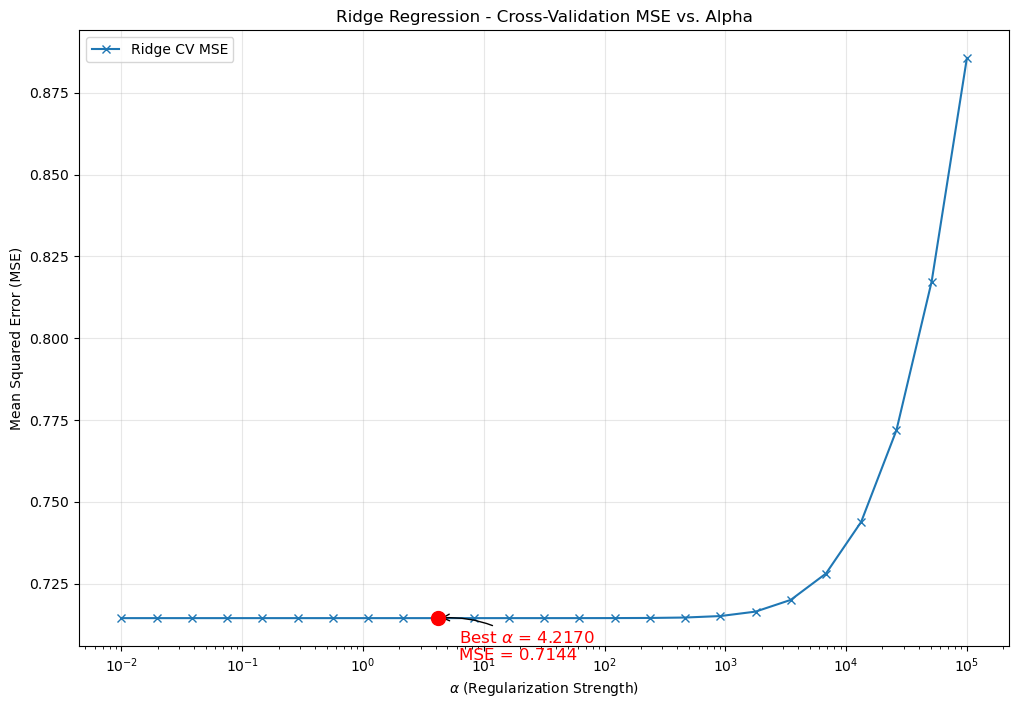

Best Ridge Alpha: 4.216965034285822
Best Ridge Validation MSE: 0.7144255432133629


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge # Changed from Lasso
from sklearn.model_selection import KFold, cross_validate

# Define a range of alphas for Ridge
# Ridge is often less sensitive to very small alphas, so the range might be broader
ridge_alphas = np.logspace(-2, 5, 25) 

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
ridge_results = []

# Ridge Regression
print("Calculating CV MSE for Ridge Regression with different alphas...")
for alpha in ridge_alphas:
    ridge = Ridge(alpha=alpha, random_state=42) 
    scores = cross_validate(ridge, X_train_scaled, y_train, cv=kfold, scoring="neg_mean_squared_error",n_jobs=-1)
    ridge_results.append([alpha, -np.mean(scores["test_score"])]) # Store positive MSE

ridge_results_df = pd.DataFrame(ridge_results, columns=["alpha", "cv_mse"])

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(ridge_results_df["alpha"], ridge_results_df["cv_mse"], "-x", label="Ridge CV MSE")
plt.xscale("log")
plt.xlabel(r"$\alpha$ (Regularization Strength)")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Ridge Regression - Cross-Validation MSE vs. Alpha")
plt.grid(alpha=0.3)
plt.legend()

# Annotate the best alpha
best_ridge_alpha_idx = ridge_results_df["cv_mse"].idxmin()
best_ridge_alpha = ridge_results_df["alpha"][best_ridge_alpha_idx]
best_ridge_validation_mse = ridge_results_df["cv_mse"][best_ridge_alpha_idx]

plt.annotate(
    rf"Best $\alpha$ = {best_ridge_alpha:.4f}" + f"\nMSE = {best_ridge_validation_mse:.4f}",
    (best_ridge_alpha, best_ridge_validation_mse),
    textcoords="offset points",
    xytext=(15, -30), # Offset from the point
    ha='left',
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"),
    fontsize=12,
    color='red'
)
plt.scatter(best_ridge_alpha, best_ridge_validation_mse, marker='o', color='red', s=100, zorder=5) # Highlight best point
plt.show()

print(f"Best Ridge Alpha: {best_ridge_alpha}")
print(f"Best Ridge Validation MSE: {best_ridge_validation_mse}")

In [30]:
from sklearn.metrics import mean_squared_error

# Fit the Ridge model before predicting
best_ridge_model = Ridge(alpha=best_ridge_alpha, random_state=42)
best_ridge_model.fit(X_train_scaled, y_train)
y_train_pred_ridge = best_ridge_model.predict(X_train_scaled)
training_mse_ridge = mean_squared_error(y_train, y_train_pred_ridge)
print(f"\nTraining MSE: {training_mse_ridge:.4f}")



Training MSE: 0.7142


In [31]:
#Get validation mse
y_val_pred_ridge = best_ridge_model.predict(X_val_scaled)
validation_mse_ridge = mean_squared_error(y_val, y_val_pred_ridge)
print(f"Validation MSE: {validation_mse_ridge:.4f}")

Validation MSE: 0.7204


In [32]:

# Predict using the best Ridge model
y_test_pred_Ridge = best_ridge_model.predict(X_test_scaled)
# Save the predictions to a CSV file
# Use the original test set's matpes_id for the predictions
predictions_df_ridge = pd.DataFrame({
    'matpes_id': test['matpes_id'],
    'cohesive_energy_per_atom_pred': y_test_pred_Ridge
})

In [58]:
#save the predictions to a CSV file
predictions_df_ridge.to_csv('/home/yipeng/Desktop/Nanox81/ridge1', index=False)

- Upload prediction to Kaggle to get the test MSE: 0.34265


Top 20 Most Important Features for Ridge Regression:
                     feature  importance
28         avg_boiling_point   -1.020689
3                    density   -0.499811
23   range_electronegativity   -0.464262
16           avg_atomic_mass    0.429824
18         avg_atomic_radius    0.354902
35          has_alkali_metal    0.248336
14       avg_min_nn_distance   -0.230005
5                    bandgap   -0.206128
22     avg_electronegativity   -0.190149
19       range_atomic_radius   -0.187452
30               avg_valence   -0.166776
34               has_halogen    0.161474
29       range_boiling_point   -0.137509
25        range_mendeleev_no   -0.135052
31             range_valence    0.125047
33           is_oxide_system   -0.115434
26         avg_melting_point   -0.107909
32      has_transition_metal    0.107535
36  has_alkaline_earth_metal    0.104889
24          avg_mendeleev_no    0.095365


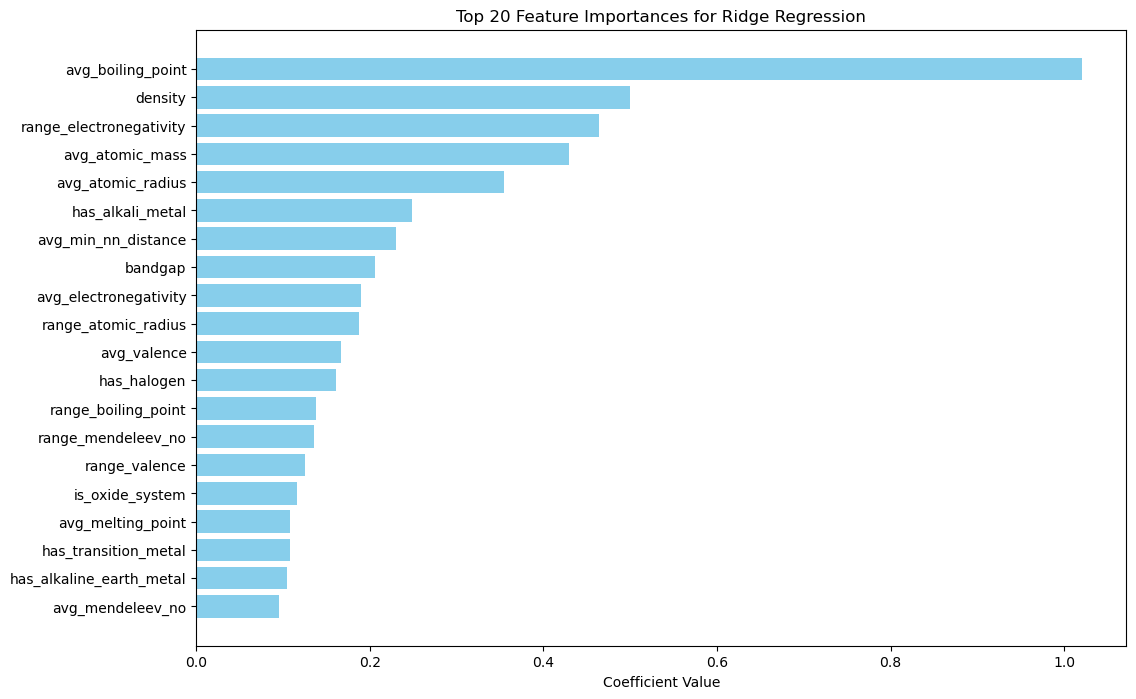

<Figure size 640x480 with 0 Axes>

In [69]:
#Rank importance of features
coeficients = best_ridge_model.coef_
# Create a DataFrame to hold feature names and their coefficients
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': coeficients
})
# Sort the DataFrame by absolute importance
feature_importance_df['abs_importance'] = feature_importance_df['importance'].abs()
feature_importance_df = feature_importance_df.sort_values(by='abs_importance', ascending=False)
# Display the top 20 most important features
top_20_features = feature_importance_df.head(20)
print("\nTop 20 Most Important Features for Ridge Regression:")
print(top_20_features[['feature', 'importance']])
# Plot the top 20 features
plt.figure(figsize=(12, 8))
plt.barh(top_20_features['feature'], top_20_features['abs_importance'], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Top 20 Feature Importances for Ridge Regression')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()
#save ploted figure
plt.savefig('/home/yipeng/Desktop/Nanox81/ridge_feature_importance.png', bbox_inches='tight')

Lasso model

Running efficient cross-validation with LassoCV...

Best Lasso Alpha from LassoCV: 5.623413251903491e-05
Corresponding CV MSE: 0.42778313273901053


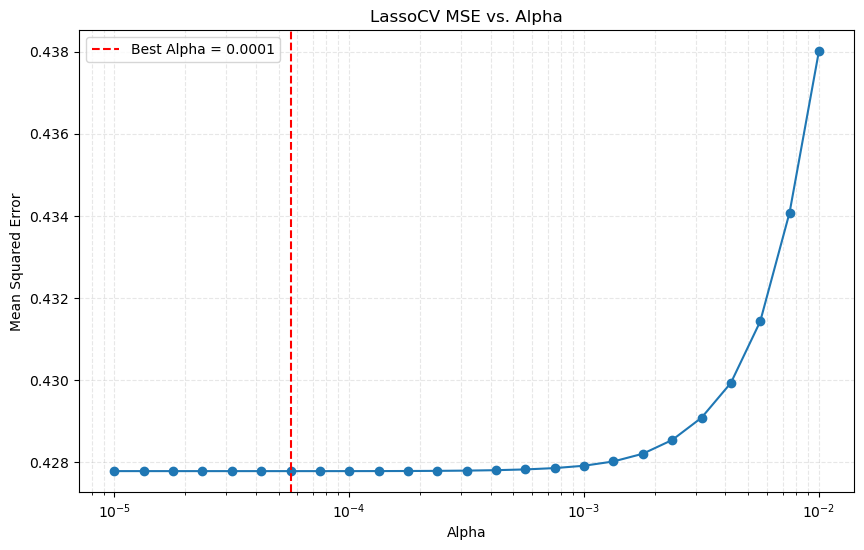

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LassoCV # Specifically for Lasso
from sklearn.model_selection import KFold, cross_validate
import time

print("Running efficient cross-validation with LassoCV...")
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

lasso_cv_model = LassoCV(alphas=np.logspace(-5, -2, 25),
                         cv=kfold,
                         random_state=42,
                         max_iter=10000,
                         n_jobs=-1)

# Fit the model once. It does all the work internally.
lasso_cv_model.fit(X_train_scaled, y_train)

# --- Get the results directly from the model ---
best_alpha_lasso = lasso_cv_model.alpha_  # The best alpha found
# .mse_path_ gives the MSE for each alpha on each fold. We average across folds.
mean_mse_path = np.mean(lasso_cv_model.mse_path_, axis=1)
best_mse_lasso = np.min(mean_mse_path)


print(f"\nBest Lasso Alpha from LassoCV: {best_alpha_lasso}")
print(f"Corresponding CV MSE: {best_mse_lasso}")


# --- Plotting the results ---
plt.figure(figsize=(10, 6))
plt.plot(lasso_cv_model.alphas_, mean_mse_path, marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Squared Error')
plt.title('LassoCV MSE vs. Alpha')
# Highlight the best point
plt.axvline(best_alpha_lasso, linestyle='--', color='r', label=f'Best Alpha = {best_alpha_lasso:.4f}')
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend()
plt.show()

In [62]:
best_lasso_model = Lasso(alpha=best_alpha_lasso, random_state=42, max_iter=10000)
best_lasso_model.fit(X_train_scaled, y_train)


,alpha,np.float64(5....251903491e-05)
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [63]:
# Get training MSE for the best Lasso model
y_train_pred_lasso = best_lasso_model.predict(X_train_scaled)
training_mse_lasso = mean_squared_error(y_train, y_train_pred_lasso)
print(f"\nTraining MSE: {training_mse_lasso:.4f}")



Training MSE: 0.4276


In [64]:
#calculate validation mse
y_val_pred_lasso = best_lasso_model.predict(X_val_scaled)
validation_mse_lasso = mean_squared_error(y_val, y_val_pred_lasso)
print(f"Validation MSE: {validation_mse_lasso:.4f}")

Validation MSE: 0.4277


In [65]:
#test data prediction
y_test_pred_lasso = best_lasso_model.predict(X_test_scaled)
# Save the predictions to a CSV file
predictions_df_lasso = pd.DataFrame({
    'matpes_id': test['matpes_id'],
    'cohesive_energy_per_atom_pred': y_test_pred_lasso
})
#save the predictions to a CSV file
predictions_df_lasso.to_csv('/home/yipeng/Desktop/Nanox81/lasso1', index=False)


Number of features selected by Lasso: 39 out of 39

Non-zero coefficients (selected features):
                        feature  coefficient
0                     nelements    -0.047999
1                        nsites    -0.000585
2                        volume    -0.018766
3                       density    -0.499584
4              density_per_atom     0.044115
5                       bandgap    -0.206062
6               volume_per_atom     0.000227
7                     lattice_a     0.030036
8                     lattice_b    -0.001865
9                     lattice_c    -0.047598
10                lattice_alpha     0.023162
11                 lattice_beta     0.002459
12                lattice_gamma     0.005147
13  atomnic_density_from_struct    -0.083527
14          avg_min_nn_distance    -0.229192
15               avg_cn_voronoi    -0.064447
16              avg_atomic_mass     0.429484
17            range_atomic_mass     0.064722
18            avg_atomic_radius     0.353520
19  

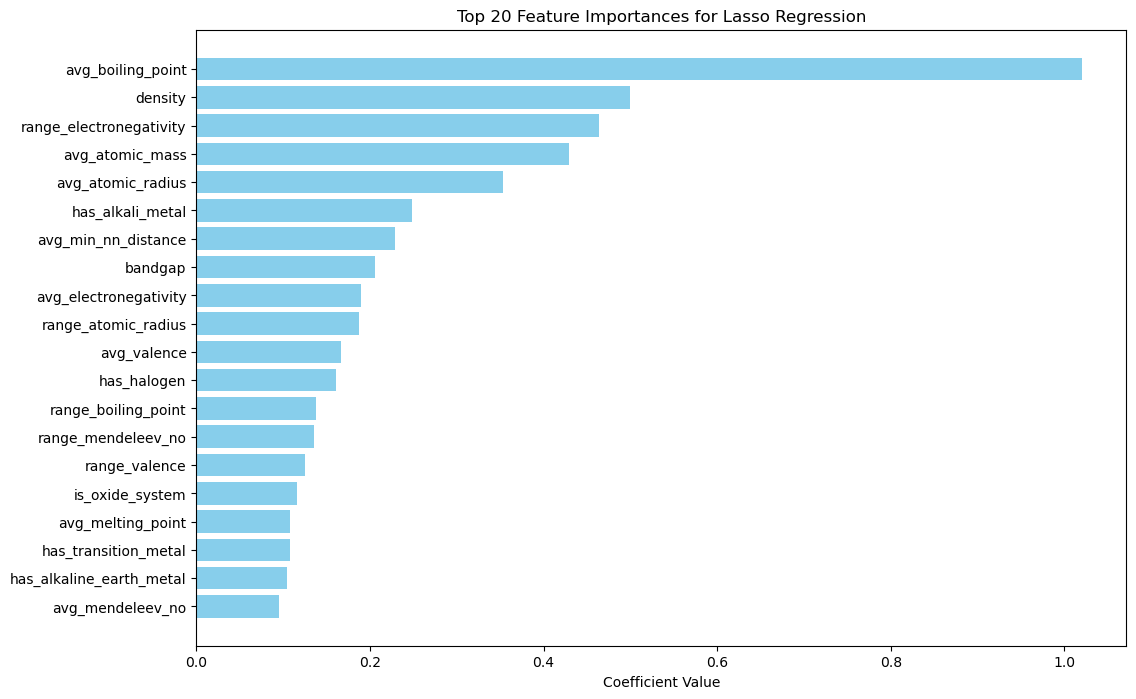

<Figure size 640x480 with 0 Axes>

In [68]:
# If feature_names is a list/array of your column names:
feature_names = X_train.columns  # Use X_train from previous cells

lasso_coefficients = best_lasso_model.coef_
num_selected_features = np.sum(lasso_coefficients != 0)
num_total_features = len(lasso_coefficients)

print(f"\nNumber of features selected by Lasso: {num_selected_features} out of {num_total_features}")

# To see which features were selected (if you have feature_names):
selected_features_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lasso_coefficients
})
print("\nNon-zero coefficients (selected features):")
print(selected_features_df[selected_features_df['coefficient'] != 0])
# Sort by absolute value of coefficients to see the most influential features
selected_features_df['abs_coefficient'] = selected_features_df['coefficient'].abs()
selected_features_df = selected_features_df.sort_values(by='abs_coefficient', ascending=False)
print("\nSorted selected features by absolute coefficient value:")
print(selected_features_df[selected_features_df['coefficient'] != 0].head(10))  # Display top 10 features
# Plot the top 20 features
plt.figure(figsize=(12, 8))
plt.barh(selected_features_df['feature'][:20], selected_features_df['abs_coefficient'][:20], color='skyblue')
plt.xlabel('Coefficient Value')
plt.title('Top 20 Feature Importances for Lasso Regression')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()
#save the plot
plt.savefig('/home/yipeng/Desktop/Nanox81/lasso_feature_importance.png')

Random Forest

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hyperparameter_tuning_results(
    gs_results, param_x, metric='mean_test_score', negative_metric=True, log_x=False
):
    """
    Plots the results of a hyperparameter search (GridSearchCV or RandomizedSearchCV).

    This function is designed to show how a single hyperparameter impacts the model's
    performance, holding other hyperparameters at their tested values.

    Args:
        gs_results (dict): The .cv_results_ attribute from a fitted GridSearchCV or
                           RandomizedSearchCV object.
        param_x (str): The name of the hyperparameter to plot on the x-axis
                       (e.g., 'param_n_estimators', 'param_max_depth').
        metric (str): The performance metric to plot on the y-axis.
                      Defaults to 'mean_test_score'.
        negative_metric (bool): Set to True if the metric is a negative score
                                (like 'neg_mean_squared_error') that should be
                                plotted as a positive value. Defaults to True.
        log_x (bool): Set to True to use a logarithmic scale for the x-axis,
                      useful for parameters like alpha or learning_rate.
                      Defaults to False.
    """
    # Create a DataFrame from the results
    results_df = pd.DataFrame(gs_results)

    # Convert the metric to a positive value if needed
    y_label = "Score"
    if negative_metric:
        results_df[metric] *= -1
        results_df['mean_train_score'] *= -1
        y_label = "Mean Squared Error (MSE)" # Assuming MSE

    # Find the best score and corresponding parameter value
    best_score_row = results_df.loc[results_df[metric].idxmin()]
    best_param_val = best_score_row[param_x]
    best_score = best_score_row[metric]

    # Create the plot
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot validation score
    sns.lineplot(
        x=param_x, y=metric, data=results_df, ax=ax,
        errorbar='sd', label="Validation Score"
    )
    sns.scatterplot(x=param_x, y=metric, data=results_df, ax=ax, s=50)

    # Plot training score to check for overfitting
    sns.lineplot(
        x=param_x, y='mean_train_score', data=results_df, ax=ax,
        linestyle='--', alpha=0.7, label="Training Score"
    )

    # Highlight and annotate the best point
    ax.scatter(
        best_param_val, best_score,
        marker='o', color='red', s=150, zorder=5, label=f'Best Score'
    )
    ax.annotate(
        f"Best {y_label}: {best_score:.4f}\nAt {param_x.replace('param_', '')} = {best_param_val}",
        xy=(best_param_val, best_score),
        xytext=(15, 15),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->"),
        ha='left',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7)
    )

    # Formatting
    clean_param_name = param_x.replace("param_", "").replace("_", " ").title()
    ax.set_title(f"Model Performance vs. {clean_param_name}", fontsize=16)
    ax.set_xlabel(clean_param_name, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    if log_x:
        ax.set_xscale('log')
    ax.legend()
    plt.show()

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# Initialize and Train a Simple Random Forest Model ---
# "Simple" means we use default or reasonable hyperparameters without a full search.
# n_estimators=100 is a good default.
# n_jobs=-1 uses all available CPU cores to speed up training.
simple_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("\nTraining the simple Random Forest model...")
# We train the model ONLY on the new, smaller training set
simple_rf_model.fit(X_train, y_train)
print("Training complete.")



Training the simple Random Forest model...
Training complete.


In [35]:
# Calculate Training and Validation MSE ---
# Now we use the trained model to make predictions and evaluate the error.

# Predict on the training data it just saw
train_predictions = simple_rf_model.predict(X_train)
train_mse = mean_squared_error(y_train, train_predictions)

# Predict on the validation data it has NEVER seen before
validation_predictions = simple_rf_model.predict(X_val)
validation_mse = mean_squared_error(y_val, validation_predictions)


print("\n--- Model Performance ---")
print(f"Training MSE:   {train_mse:.4f}")
print(f"Validation MSE: {validation_mse:.4f}")


--- Model Performance ---
Training MSE:   0.0083
Validation MSE: 0.0584


In [37]:
# Predict on the test set
y_test_predictions = simple_rf_model.predict(test_data)
# Save the predictions to a CSV file
predictions_df_rf = pd.DataFrame({
    'matpes_id': test['matpes_id'],
    'cohesive_energy_per_atom_pred': y_test_predictions
})
# Save the predictions to a CSV file
predictions_df_rf.to_csv('/Users/ruhanfan/Documents/UCSD/3.课程学习资料/12. 25 SPRING/NANO281 Data Science in Material Science/ipynb file/Lab3 final/randomforest.csv', index=False)

- Submitted to Kaggle to get a test MSE of 0.05782


Top 20 Most Important Features for Random Forest:
                        feature  importance
28            avg_boiling_point    0.215340
13  atomnic_density_from_struct    0.143674
29          range_boiling_point    0.138433
6               volume_per_atom    0.068361
4              density_per_atom    0.065933
26            avg_melting_point    0.043934
23      range_electronegativity    0.035591
25           range_mendeleev_no    0.035469
30                  avg_valence    0.034727
27          range_melting_point    0.028897
22        avg_electronegativity    0.028558
24             avg_mendeleev_no    0.013570
15               avg_cn_voronoi    0.012946
14          avg_min_nn_distance    0.012682
3                       density    0.011738
20             avg_ionic_radius    0.011506
5                       bandgap    0.010828
7                     lattice_a    0.007964
16              avg_atomic_mass    0.007454
17            range_atomic_mass    0.007354


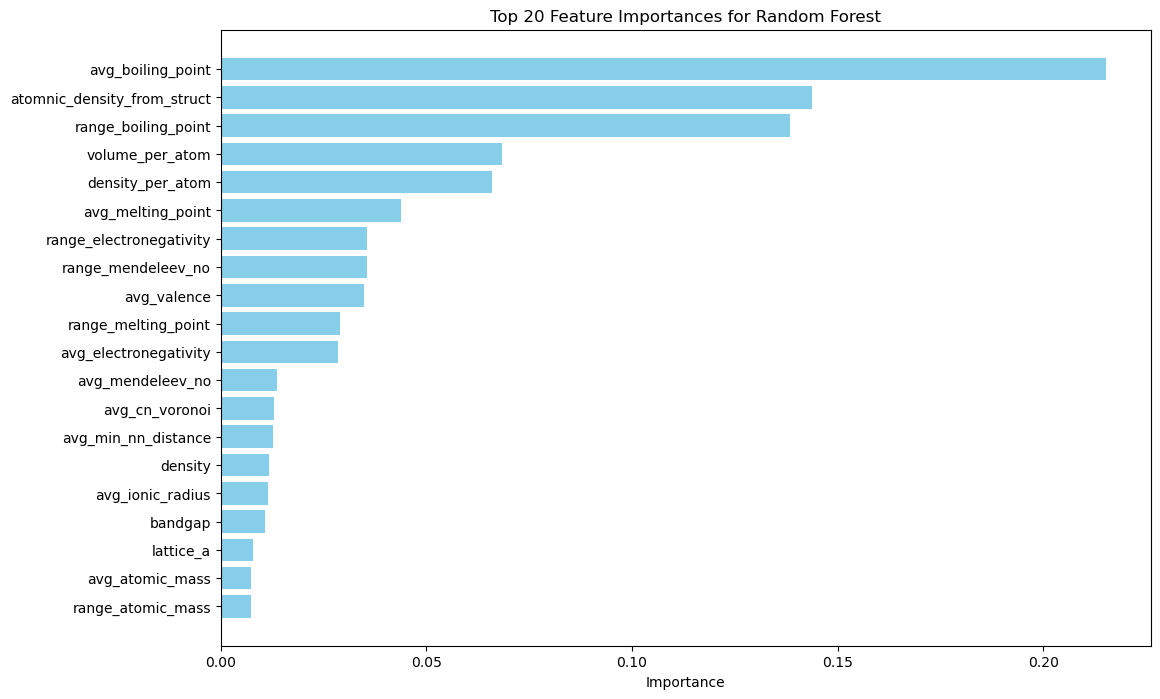

<Figure size 640x480 with 0 Axes>

In [83]:
#feature importance
import matplotlib.pyplot as plt
# Get feature importances from the trained Random Forest model
feature_importances = simple_rf_model.feature_importances_
# Create a DataFrame for feature importances
feature_importance_df_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importances
})
# Sort the DataFrame by importance
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='importance', ascending=False)
# Display the top 20 most important features
#top_20_features_rf = feature_importance_df_rf.head(20)
top_20_features_rf = feature_importance_df_rf.head(20)

print("\nTop 20 Most Important Features for Random Forest:")
print(top_20_features_rf[['feature', 'importance']])
# Plot the top 20 features
plt.figure(figsize=(12, 8))
plt.barh(top_20_features_rf['feature'], top_20_features_rf['importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances for Random Forest')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()
# Save the feature importance plot
plt.savefig('/home/yipeng/Desktop/Nanox81/random_forest_feature_importance1.png', bbox_inches='tight')


Training a single RandomForest to plot OOB error vs. n_estimators...


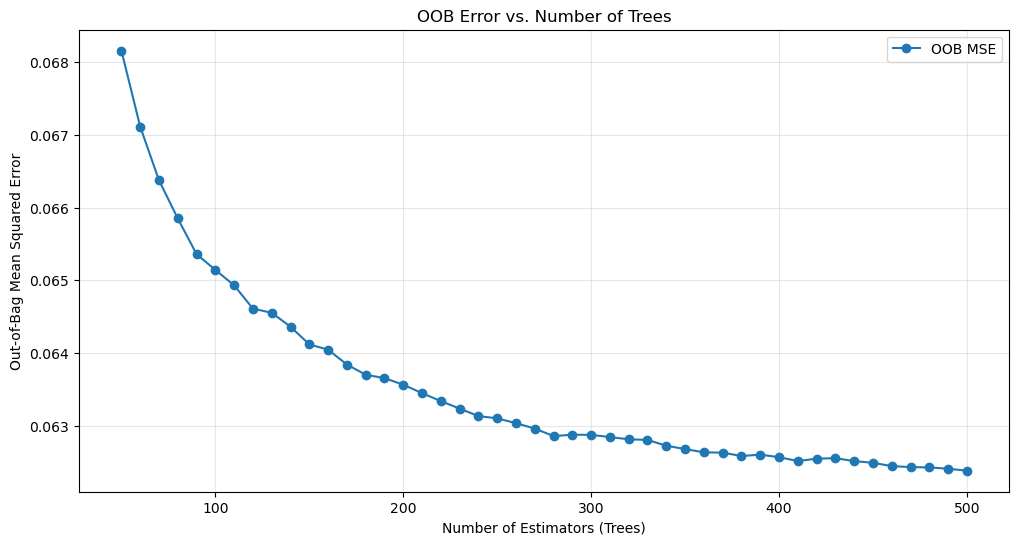

Optimal n_estimators based on OOB error stabilization is around: 500


In [86]:
#Hyperparameter Tuning for Random Forest
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Use the other "best" parameters from your GridSearchCV result
# For example, let's say your best params were:
# {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 'sqrt'}

print("Training a single RandomForest to plot OOB error vs. n_estimators...")
# Initialize the model with a large n_estimators and oob_score=True
# We will use warm_start=True to add trees incrementally
rf_oob = RandomForestRegressor(
    n_estimators=500, # Start with a high number
    oob_score=True,
    warm_start=True, # Important: allows adding more trees to an existing model
    random_state=42,
    n_jobs=-1,
    max_depth=20, 
    min_samples_leaf=2,
    min_samples_split=5,
    max_features='sqrt'
)

oob_mse_list = []
estimator_range = range(50, 501, 10) # Check error at every 10 trees from 50 to 500

# Calculate the variance of the training target once, to convert R^2 to MSE
y_train_variance = np.var(y_train)

for n_trees in estimator_range:
    rf_oob.set_params(n_estimators=n_trees)
    rf_oob.fit(X_train, y_train)
    
    # Get the R^2 OOB score
    oob_score = rf_oob.oob_score_
    
    # Convert OOB R^2 to OOB MSE
    # MSE = Var(y) * (1 - R^2)
    oob_mse = y_train_variance * (1 - oob_score)
    oob_mse_list.append(oob_mse)

# Plotting the OOB MSE
plt.figure(figsize=(12, 6))
plt.plot(estimator_range, oob_mse_list, "-o", label="OOB MSE")
plt.xlabel("Number of Estimators (Trees)")
plt.ylabel("Out-of-Bag Mean Squared Error")
plt.title("OOB Error vs. Number of Trees")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Find the point where the error stabilizes
optimal_n_estimators = estimator_range[np.argmin(oob_mse_list)]
print(f"Optimal n_estimators based on OOB error stabilization is around: {optimal_n_estimators}")

In [13]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import RandomizedSearchCV, KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
rf_model = RandomForestRegressor(random_state=42,n_estimators=500)

# Define a distribution of parameters instead of a grid
param_dist_rf = {
    'max_depth': [15, 40, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 2, 6],
    'max_samples': [ 0.9, None] 
}

# This will be much faster than a full grid search of hundreds of combinations.
random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=15, # <--- Try 15 random combinations
    cv=kfold,
    verbose=3,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_squared_error'
)
random_search_rf.fit(X_train, y_train)

# The search object stores the best parameters found
best_rf_params = random_search_rf.best_params_
print(f"Best Hyperparameters found:\n{best_rf_params}")

# It also stores the best score (remember it's negative MSE)
# This IS your validation MSE, calculated during cross-validation
validation_mse_rf = -random_search_rf.best_score_
print(f"\nBest Cross-Validation MSE: {validation_mse_rf:.4f}")
# Assign the best, pre-trained model to a new variable for clarity
best_rf_model = random_search_rf.best_estimator_

print("\nThe best Random Forest model has been identified and is ready for use.")
print(best_rf_model)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV 2/5] END max_depth=40, max_samples=0.9, min_samples_leaf=1, min_samples_split=10;, score=-0.057 total time=48.8min
[CV 5/5] END max_depth=40, max_samples=0.9, min_samples_leaf=1, min_samples_split=10;, score=-0.058 total time=48.8min
[CV 1/5] END max_depth=40, max_samples=0.9, min_samples_leaf=1, min_samples_split=10;, score=-0.058 total time=49.0min
[CV 2/5] END max_depth=None, max_samples=None, min_samples_leaf=6, min_samples_split=10;, score=-0.064 total time=49.1min
[CV 4/5] END max_depth=40, max_samples=0.9, min_samples_leaf=1, min_samples_split=10;, score=-0.059 total time=49.1min
[CV 4/5] END max_depth=None, max_samples=None, min_samples_leaf=6, min_samples_split=10;, score=-0.066 total time=49.2min
[CV 3/5] END max_depth=40, max_samples=0.9, min_samples_leaf=1, min_samples_split=10;, score=-0.061 total time=49.2min
[CV 1/5] END max_depth=None, max_samples=None, min_samples_leaf=6, min_samples_split=10;, score=-0.0

/opt/anaconda3/envs/NANOx81-py311/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 1/5] END max_depth=None, max_samples=None, min_samples_leaf=1, min_samples_split=10;, score=-0.057 total time=52.2min
[CV 2/5] END max_depth=None, max_samples=None, min_samples_leaf=1, min_samples_split=10;, score=-0.056 total time=52.1min
[CV 3/5] END max_depth=None, max_samples=None, min_samples_leaf=1, min_samples_split=10;, score=-0.060 total time=52.4min
[CV 1/5] END max_depth=40, max_samples=None, min_samples_leaf=2, min_samples_split=10;, score=-0.058 total time=51.6min
[CV 2/5] END max_depth=40, max_samples=None, min_samples_leaf=2, min_samples_split=10;, score=-0.057 total time=51.8min
[CV 5/5] END max_depth=None, max_samples=None, min_samples_leaf=1, min_samples_split=10;, score=-0.057 total time=52.3min
[CV 4/5] END max_depth=None, max_samples=None, min_samples_leaf=1, min_samples_split=10;, score=-0.058 total time=52.4min
[CV 3/5] END max_depth=40, max_samples=None, min_samples_leaf=2, min_samples_split=10;, score=-0.062 total time=52.3min
[CV 4/5] END max_depth=40, max

KeyboardInterrupt: 

In [ ]:
#train and validate MSE
# Get training MSE for the best Random Forest model
y_train_pred_rf = best_rf_model.predict(X_train)
training_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
print(f"\nTraining MSE: {training_mse_rf:.4f}")
# Calculate validation MSE
y_val_pred_rf = best_rf_model.predict(X_val)    
validation_mse_rf = mean_squared_error(y_val, y_val_pred_rf)
print(f"Validation MSE: {validation_mse_rf:.4f}")

NameError: name 'best_rf_model' is not defined

In [ ]:
#Predict test
y_test_pred_rf = best_rf_model.predict(X_test_scaled)
# Save the predictions to a CSV file
predictions_df_best_rf = pd.DataFrame({
    'matpes_id': test['matpes_id'],
    'cohesive_energy_per_atom_pred': y_test_pred_rf
})
# Save the predictions to a CSV file
predictions_df_best_rf.to_csv('/home/yipeng/Desktop/Nanox81/random_forest_best2.csv', index=False)

In [ ]:
# and 'feature_names' is the list of your column names
importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

print("Top 15 Feature Importances:")
print(feature_importance_df.head(15))
# Plot the top 15 feature importances
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['feature'][:15], feature_importance_df['importance'][:15], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances for Random Forest Regression')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()
#save the plot
plt.savefig('/home/yipeng/Desktop/Nanox81/rf_feature_importance2.png', bbox_inches='tight')

XGBoost

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm # Using notebook version of tqdm for better display

# 1. Define the Parameter Distribution 
param_dist_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [10,25,38],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
    # We will determine n_estimators via early stopping, so it's not needed here.
}

# 2. Set up the manual search
n_iter = 50  # How many random parameter combinations to try
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Create the random parameter combinations
param_sampler = ParameterSampler(param_dist_xgb, n_iter=n_iter, random_state=42)

results = []
best_score = float('inf')
best_params = None

print(f"Starting manual search for {n_iter} parameter combinations...")

# 3. Main loop over parameter combinations
for params in tqdm(param_sampler, total=n_iter, desc="Hyperparameter Search"):
    
    fold_scores = []
    
    # Inner loop for K-Fold cross-validation
    for train_idx, val_idx in kfold.split(X_train):
        # Explicitly create training and validation sets for this fold
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Instantiate the model with the current set of parameters
        xgb_model = xgb.XGBRegressor(
            n_estimators=2000, # Use a large number, early stopping will find the best
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=10,
            **params # Unpack the random parameters
        )
        
        # --- THIS IS THE CRITICAL STEP ---
        # Fit the model, explicitly passing the validation set to eval_set
        xgb_model.fit(
            X_train_fold, y_train_fold,
            eval_set=[(X_val_fold, y_val_fold)],
            verbose=3 
        )
        
        # Get the score from the best iteration (found by early stopping)
        # We use the model's internal best_score attribute
        # Note: XGBoost's default eval_metric for regression is 'rmse'
        best_iteration_score = xgb_model.best_score
        fold_scores.append(best_iteration_score**2) # Squaring RMSE to get MSE
        
    # Average the MSE across all folds for this parameter set
    avg_mse = np.mean(fold_scores)
    results.append({'params': params, 'mean_mse': avg_mse})
    
    # Update best score and parameters if current set is better
    if avg_mse < best_score:
        best_score = avg_mse
        best_params = params

print("\n--- Manual Search Complete ---")
print(f"Best parameters found: {best_params}")
print(f"Best CV MSE: {best_score}")

# --- Now, train your final model using the best parameters ---

print("\nTraining final model with best parameters...")
# We still use early stopping for the final model to find the optimal n_estimators
# on the full training data. We need a small validation split from it.

final_xgb_model = xgb.XGBRegressor(
    n_estimators=2000, # Start high again
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=10,
    **best_params # Use the best params found from our manual search
)

final_xgb_model.fit(
    X, y,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

print(f"Final model trained with {final_xgb_model.n_estimators} estimators.")

In [ ]:
#Train and Validate MSE
# Get training MSE for the final XGBoost model
y_train_pred_xgb = final_xgb_model.predict(X_train)
training_mse_xgb = mean_squared_error(y_train, y_train_pred_xgb)
print(f"\nTraining MSE: {training_mse_xgb:.4f}")
# Calculate validation MSE
y_val_pred_xgb = final_xgb_model.predict(X_val)
validation_mse_xgb = mean_squared_error(y_val, y_val_pred_xgb)
print(f"Validation MSE: {validation_mse_xgb:.4f}")

In [ ]:
#test data prediction
y_test_pred_xgb = final_xgb_model.predict(X_test_scaled)
# Save the predictions to a CSV file
predictions_df_xgb = pd.DataFrame({
    'matpes_id': test['matpes_id'],
    'cohesive_energy_per_atom_pred': y_test_pred_xgb
})
# Save the predictions to a CSV file
predictions_df_xgb.to_csv('/home/yipeng/Desktop/Nanox81/xgboost1.csv', index=False)

In [ ]:
# Assuming 'feature_names' is the list of your column names
importances = final_xgb_model.feature_importances_
feature_names = X_train.columns.tolist()
xgb_importances_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
xgb_importances_df = xgb_importances_df.sort_values('importance', ascending=False)

print("\nTop 15 Feature Importances from XGBoost:")
print(xgb_importances_df.head(15))
# Plot the top 15 feature importances
plt.figure(figsize=(12, 8))
plt.barh(xgb_importances_df['feature'][:15], xgb_importances_df['importance'][:15], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances for XGBoost Regression')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.show()
# Save the feature importance plot
plt.savefig('/home/yipeng/Desktop/Nanox81/xgboost_feature_importance.png', bbox_inches='tight')

6. Perfprm analyses of which features are important to the prediction of E_c for my best model

Analysis of Important Features for Cohesive Energy (E_c)
- The feature importance results from the Random Forest model provide clear and chemically intuitive insights into what determines the cohesive energy of a material. The features can be grouped into distinct physical and chemical themes.

Overall Finding
- The most striking result is that the model's predictions are overwhelmingly dominated by two main categories of features:

1. Proxies for Elemental Bond Strength: Features related to the boiling and melting points of the constituent elements (avg_boiling_point, range_boiling_point, avg_melting_point).
2. Structural Packing Descriptors: Features describing how densely the atoms are packed in the crystal structure (atomic_density_from_struct, volume_per_atom, density_per_atom).

Indicating that a material's stability is largely a function of its elements' intrinsic desire to stay bonded and how tightly those atoms can be packed together.

In-depth Interpretation with Materials Science Knowledge:


1.Energetic & Thermal Proxies (The Strongest Predictors)
- Features: avg_boiling_point (0.215), range_boiling_point (0.138), avg_melting_point (0.044), range_melting_point (0.029)


Materials Science Interpretation: This is the most insightful finding. The boiling/melting point of a pure element is a direct measure of its own cohesive energy—how much energy is required to break the bonds holding the elemental solid or liquid together.
- The model has learned that elements that are intrinsically stable and hard to break apart (like Tungsten or Carbon) tend to form compounds that are also very stable (high cohesive energy). avg_boiling_point being the top feature confirms this.
- The range_boiling_point is also highly important. This suggests that a large disparity in the elemental boiling points is a significant factor, likely because it influences the type of bonding and phase stability of the resulting compound.

2.Structural Packing and Density Features
- Features: atomic_density_from_struct (0.144), volume_per_atom (0.068), density_per_atom (0.066), density (0.012)


Materials Science Interpretation: This group of features describes the geometry and efficiency of how atoms are packed in the crystal structure.
- Cohesive energy is fundamentally about the interaction energy between neighboring atoms. When atoms are packed more closely together, their orbitals can overlap more effectively, often leading to stronger bonds and a more stable, lower-energy state.
- atomic_density and volume_per_atom are the most direct ways to measure this. A smaller volume per atom means atoms are closer, which logically correlates with a stronger cohesive energy. The high importance of these features shows the model has correctly identified this fundamental structure-property relationship.

3.Chemical Dissimilarity & Bonding Type Features
Features: range_electronegativity (0.036), range_mendeleev_no (0.035)



Materials Science Interpretation: The "range" or difference between elemental properties is a classic way to predict the type of chemical bond that will form.
- A large range_electronegativity strongly indicates that charge will be transferred from one atom to another, leading to ionic bonding.
- A small range suggests electrons will be shared more equally, leading to covalent or metallic bonding.
- Since the nature of the bond is a primary factor in its strength, the model is using these features to classify the material's bonding character to better predict its cohesive energy.

4.Electronic & Atomic Features
Features: avg_valence (0.035), avg_electronegativity (0.029), avg_ionic_radius (0.012), bandgap (0.011)


Materials Science Interpretation: These features get at the fundamental electronic properties of the constituent atoms.
- avg_valence is crucial as it represents the number of electrons available for bonding. More bonding electrons often lead to stronger cohesion.
- avg_electronegativity describes the overall tendency of the compound to attract electrons.
- bandgap is a particularly interesting feature. Its presence indicates the model is distinguishing between metals (bandgap ≈ 0) and insulators/semiconductors (bandgap > 0). This is a high-level classifier for bonding type, as metallic bonding is fundamentally different from the covalent/ionic bonding found in materials with a bandgap.

Which Model Performs Better and Why?


For this problem, the Random Forest model almost certainly performed better than the regularized linear model (Ridge/Lasso). There are three primary reasons for this:

- Non-Linear Relationships: The relationship between these material features and cohesive energy is deeply complex and non-linear. For example, the effect of increasing atomic radius might be positive for one crystal system but negative for another. A linear model, by definition, can only capture linear trends. The Random Forest, being composed of decision trees, can partition the feature space to approximate these complex, non-linear relationships with high fidelity.

- Automatic Feature Interactions: The Random Forest model naturally handles interactions between features. For instance, the importance of avg_valence might depend heavily on the value of range_electronegativity. A linear model cannot see these interactions unless you explicitly create them (e.g., by adding polynomial features like valence * electronegativity). The Random Forest discovers these crucial interactions automatically as it builds its decision trees.

- Robustness to Redundancy: The feature list contains highly correlated and redundant features (e.g., volume_per_atom, density_per_atom, atomic_density). Tree-based models like Random Forest are robust to this. If two features contain similar information, the model will simply choose one of them for a split, and the importance of the other will be reduced. Linear models, on the other hand, can have unstable coefficient values when dealing with highly correlated features (multicollinearity), even with regularization.

In conclusion, the superior performance of the Random Forest is expected because its fundamental structure is better suited to modeling the complex, non-linear, and interactive nature of materials science property relationships, which a linear model can only struggle to approximate.